### Libraries.

In [1]:
import sys

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import torch

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "../../scripts")
from fetch_data import fetch_adata_goattgens_sfc

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading Data.

In [2]:
PATH = "../../../theis/HID01_fcs_concatenated.h5ad"
cofactor = 10000
adata = fetch_adata_goattgens_sfc(
    PATH,
    concatenate_scatter_feats=True,
    scatter_transformation=lambda X: np.sign(X)*np.log(np.abs(X / cofactor))
)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_repr', 'X_sct'

### Subsampling the data.

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_repr', 'X_sct'

### Model.

With self.use_guidance=False an unguided flow model will be initialized, thus the settings for the condition encoder will be ignored.
Loss: 2.8509: 100%|██████████| 100000/100000 [04:47<00:00, 347.96it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

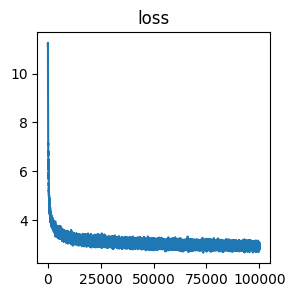

In [4]:
flow_matching = FlowMatching(
    coupling_type="independent",
    generate_from_noise=True,
)

flow_matching.prepare_train_data(
    adata,
    sample_rep="X_sct",
)
cvf_config = NeuralVelocityFieldConfig(
    flow_dim=adata.obsm["X_sct"].shape[1],
    encode_state=True,
    state_encoder_output_dim=64,
    state_encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=False,
    decoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
)
flow_matching.prepare_model(
    cvf_config,
    num_time_steps=100,
)
flow_matching.train(
    num_training_steps=100_000,
)
flow_matching.trainer.plot_training_logs()


### Generating some events.

In [5]:
samples = flow_matching.predict(
    batch={},
    batch_size=400_000,
)
sampled_channel_feats = samples[:, :adata.X.shape[1]]
sampled_scatter_feats = samples[:, adata.X.shape[1]:]
sampled_channel_feats.shape, sampled_scatter_feats.shape 


(torch.Size([400000, 21]), torch.Size([400000, 6]))

### Defining function for plotting with anndata.

In [6]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_repr", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    for color in coloring:
        if plot_pcs:
            sc.pl.embedding(adata_generated, basis=key, color=color)
        if plot_umap:
            sc.pl.umap(adata_generated, color=color)
    return adata_generated


### Visualizing the Generated Channel Features.

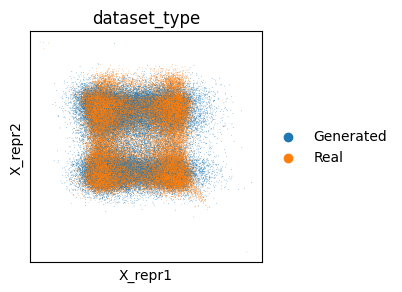

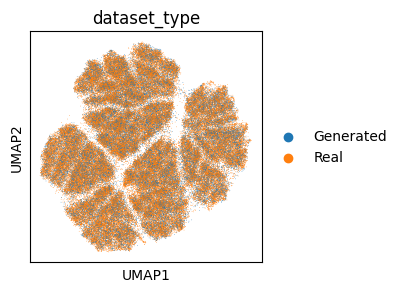

In [8]:
adata_generated = concatenate_adata_and_plot(
    adata,
    sampled_channel_feats.cpu().numpy(),
)
